# **Step2_AI 강사 Agent v2.0**

## **0. 미션**

### **미션③ : 모듈 고도화1**
다음 항목에 대해서 조 상황에 맞게 선택적으로 고도화 합니다.

* 입력 프롬프트 추가 : 강의 목소리, 톤 조절, 강의 스타일 지침
* 정보 분해 : 여러 슬라이드를 저장하고 관리하기 위한 폴더 준비, 불필요한 정보 제거, 제목 추출
* 페이지별 내용 생성 : 슬라이드 내 정보 뿐만 아니라 부연 설명을 위한 검색 기능 추가
* 강의 스크립트 생성 : 전체 강의 내용을 참조하여 강의 흐름을 구상하고,
								   현재 페이지 강의 스크립트 작성
* 내용 검토 : 페이지 내용과 강의 스크립트 비교, 강의 스크립트 흐름 적절한지 검토




### **미션④ : AI 강사 Agent 완성**
* 모듈 고도화2(다음 항목에 대해서 조 상황에 맞게 선택적으로 고도화 합니다.)
	* 음성 변환 : 강의 목소리, 톤 조절 음성 변환
	* 영상 제작 :
		* 각 페이지 : 음성과 슬라이드 스냅샷 이미지 합성하여 영상 제작하기
		* 전체 강의 영상 : 각 슬라이드 강의를 전체 슬라이드 강의 영상으로 합치기
* 웹 화면 연결(gradio)
	* 음성 변환 : 강의 목소리, 톤 조절 프롬프트 기반 음성 변환
* 전체 Agent 그래프 구축
	* 전체를 Agent 그래프로 엮기


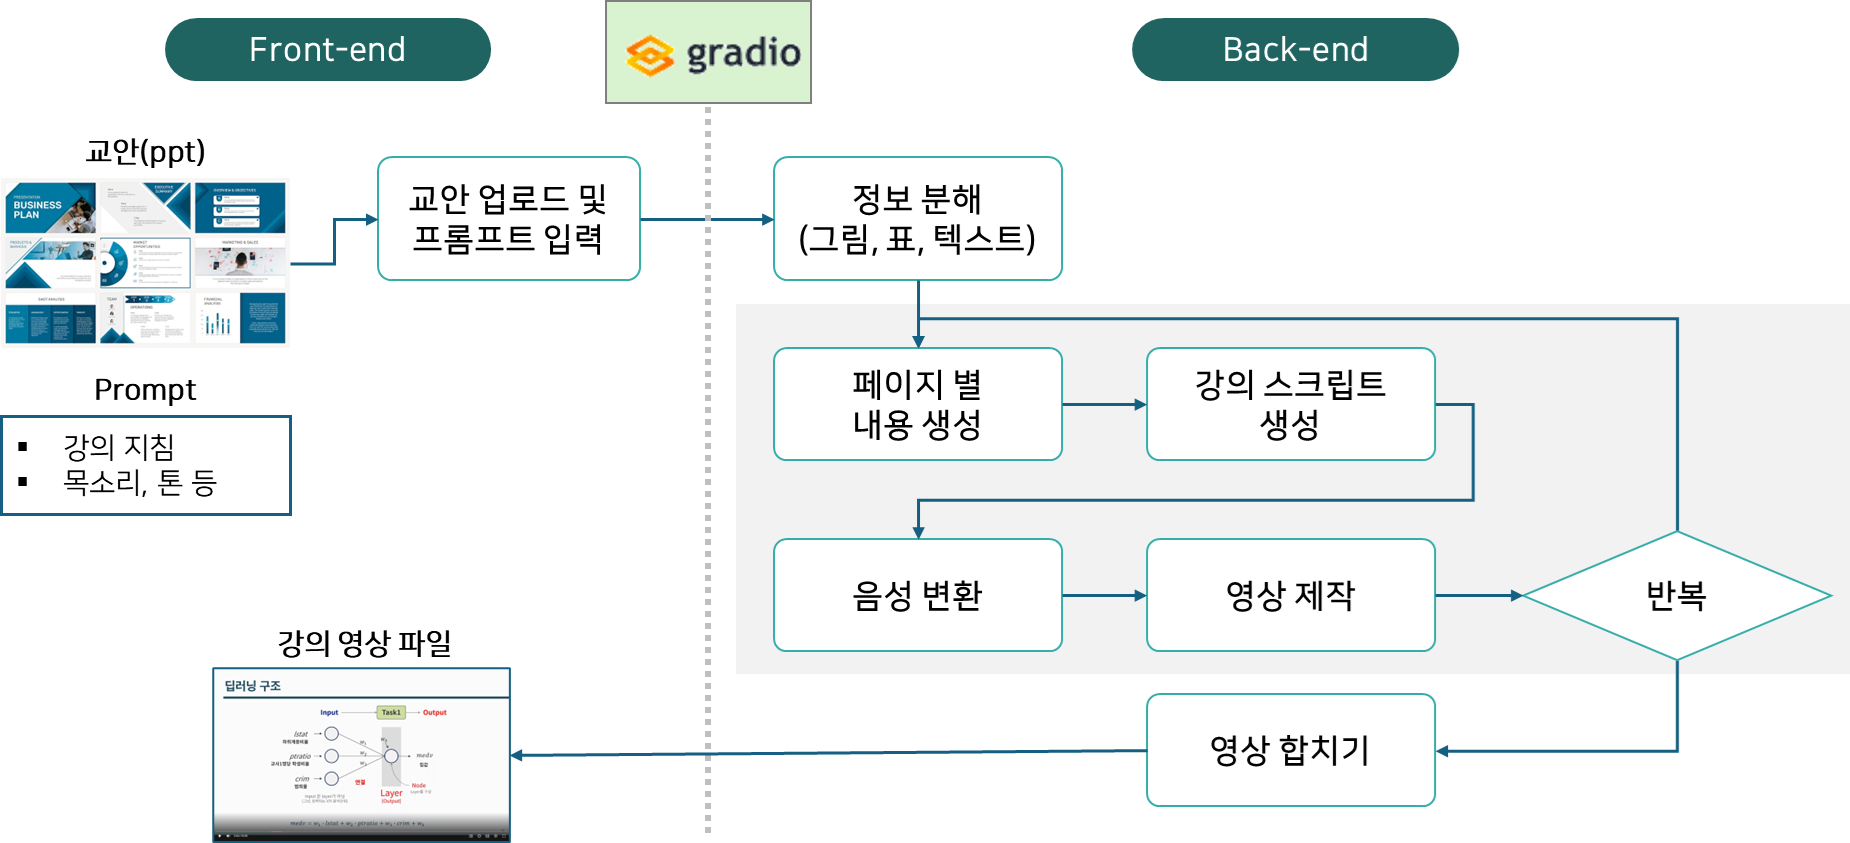

## **1. 환경준비**

### (1) 구글 드라이브

* 구글 드라이브 폴더 생성
	* 새 폴더(project_multi_modal)를 생성하고
	* 제공 받은 파일을 업로드

* 구글 드라이브 연결

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### (2) 한글 폰트 준비
* 한글 폰트 설치 및 설정 코드
* 영상 제작 등 한글 사용시 필요

In [2]:
!apt-get -y install ffmpeg libreoffice poppler-utils poppler-data locales \
				   fonts-noto-cjk fonts-noto-cjk-extra fonts-nanum fonts-unfonts-core
!sed -i 's/^# *ko_KR.UTF-8 UTF-8/ko_KR.UTF-8 UTF-8/' /etc/locale.gen
!locale-gen ko_KR.UTF-8
!update-locale LANG=ko_KR.UTF-8
!fc-cache -fv

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
locales is already the newest version (2.35-0ubuntu3.11).
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
The following additional packages will be installed:
  apparmor at-spi2-core ca-certificates-java default-jre default-jre-headless
  dictionaries-common firebird3.0-common firebird3.0-common-doc
  firebird3.0-server-core firebird3.0-utils fonts-crosextra-caladea
  fonts-crosextra-carlito fonts-dejavu fonts-dejavu-core fonts-dejavu-extra
  fonts-liberation2 fonts-linuxlibertine fonts-noto-core fonts-noto-extra
  fonts-noto-mono fonts-noto-ui-core fonts-opensymbol fonts-sil-gentium
  fonts-sil-gentium-basic gsettings-desktop-schemas gstreamer1.0-gl
  gstreamer1.0-gtk3 gstreamer1.0-plugins-base hunspell-en-us java-common
  libabsl20210324 libabw-0.1-1 libatk-bridge2.0-0 libatk-wrapper-java
  libatk-wrapper-java-jni libatk1.0-0 libatk1.0-data libatspi2.0-0
  libboost-filesy

In [3]:
%%bash
mkdir -p ~/.config/fontconfig
cat > ~/.config/fontconfig/fonts.conf <<'EOF'
<?xml version="1.0"?>
<!DOCTYPE fontconfig SYSTEM "fonts.dtd">
<fontconfig>

	<!-- ▷ 한국어 텍스트엔 Noto Sans CJK KR을 우선 사용 -->
	<match target="pattern">
		<test name="lang" compare="eq"><string>ko</string></test>
		<edit name="family" mode="prepend" binding="strong">
			<string>Noto Sans CJK KR</string>
		</edit>
	</match>

	<!-- ▷ 일반 가족명에도 기본 대체 추가 -->
	<alias><family>sans-serif</family><prefer><family>Noto Sans CJK KR</family></prefer></alias>
	<alias><family>serif</family><prefer><family>Noto Serif CJK KR</family></prefer></alias>
	<alias><family>monospace</family><prefer><family>Noto Sans Mono CJK KR</family></prefer></alias>

	<!-- ▷ Windows/macOS/웹에서 흔한 한글 폰트들을 Noto로 매핑 -->
	<alias><family>Malgun Gothic</family>        <prefer><family>Noto Sans CJK KR</family></prefer></alias>
	<alias><family>맑은 고딕</family>             <prefer><family>Noto Sans CJK KR</family></prefer></alias>
	<alias><family>Apple SD Gothic Neo</family>  <prefer><family>Noto Sans CJK KR</family></prefer></alias>
	<alias><family>AppleGothic</family>          <prefer><family>Noto Sans CJK KR</family></prefer></alias>
	<alias><family>Pretendard</family>           <prefer><family>Noto Sans CJK KR</family></prefer></alias>
	<alias><family>Pretendard Variable</family>  <prefer><family>Noto Sans CJK KR</family></prefer></alias>
	<alias><family>NanumSquare</family>          <prefer><family>Noto Sans CJK KR</family></prefer></alias>
	<alias><family>Spoqa Han Sans</family>       <prefer><family>Noto Sans CJK KR</family></prefer></alias>
	<alias><family>KoPub</family>                <prefer><family>Noto Sans CJK KR</family></prefer></alias>
	<alias><family>Gulim</family>                <prefer><family>Noto Sans CJK KR</family></prefer></alias>
	<alias><family>Dotum</family>                <prefer><family>Noto Sans CJK KR</family></prefer></alias>
	<alias><family>Batang</family>               <prefer><family>Noto Serif CJK KR</family></prefer></alias>
</fontconfig>
EOF
fc-cache -fv


/usr/share/fonts: caching, new cache contents: 0 fonts, 4 dirs
/usr/share/fonts/cMap: caching, new cache contents: 0 fonts, 0 dirs
/usr/share/fonts/cmap: caching, new cache contents: 0 fonts, 5 dirs
/usr/share/fonts/cmap/adobe-cns1: caching, new cache contents: 0 fonts, 0 dirs
/usr/share/fonts/cmap/adobe-gb1: caching, new cache contents: 0 fonts, 0 dirs
/usr/share/fonts/cmap/adobe-japan1: caching, new cache contents: 0 fonts, 0 dirs
/usr/share/fonts/cmap/adobe-japan2: caching, new cache contents: 0 fonts, 0 dirs
/usr/share/fonts/cmap/adobe-korea1: caching, new cache contents: 0 fonts, 0 dirs
/usr/share/fonts/opentype: caching, new cache contents: 0 fonts, 2 dirs
/usr/share/fonts/opentype/linux-libertine: caching, new cache contents: 13 fonts, 0 dirs
/usr/share/fonts/opentype/noto: caching, new cache contents: 80 fonts, 0 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 11 dirs
/usr/share/fonts/truetype/crosextra: caching, new cache contents: 8 fonts, 0 dirs
/usr/sh

### (3) 라이브러리

* 필요한 라이브러리 설치

In [4]:
!apt-get -y install ffmpeg libreoffice poppler-utils
!pip install python-pptx pillow langgraph google-search-results gradio -q
!pip install -q langchain_openai langchain_community chromadb

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
poppler-utils is already the newest version (22.02.0-2ubuntu0.12).
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
libreoffice is already the newest version (1:7.3.7-0ubuntu0.22.04.10).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.8/472.8 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.8/156.8 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 471.2/471.2 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.3/208.3 kB 8.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does

* 라이브러리 로딩

In [5]:
import os, re, textwrap, subprocess, json, base64, mimetypes, shlex
from pathlib import Path
from dataclasses import dataclass
from typing import List, Dict, Optional, TypedDict, Any
from PIL import Image, ImageDraw
from pptx import Presentation
from pptx.enum.shapes import MSO_SHAPE_TYPE
from openai import OpenAI
from google.colab import files
from IPython.display import Audio, display, Video
from serpapi import GoogleSearch

# 추가 라이브러리
from langchain import hub
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.output_parsers import StrOutputParser, CommaSeparatedListOutputParser
from langchain_core.prompts import PromptTemplate, ChatPromptTemplate
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.vectorstores import Chroma
from langgraph.graph import StateGraph, START, END

### (4) OpenAI API Key 확인
* 구글드라이브에 생성한 폴더 'project_multi_modal'에서
* api_key.txt 파일 안에 각자 발급 받은 키를 저장합니다.
	* **openai api key**
	* **SERPAPI_API_KEY**

In [6]:
def load_api_keys(filepath="api_key.txt"):
	with open(filepath, "r") as f:
		for line in f:
			line = line.strip()
			if line and "=" in line:
				key, value = line.split("=", 1)
				os.environ[key.strip()] = value.strip()

path = '/content/drive/MyDrive/langchain/'
# API 키 로드 및 환경변수 설정
load_api_keys(path + 'api_key.txt')

⚠️ 아래 코드셀은, 실행해서 key가 제대로 보이는지 확인하고 삭제하세요.

In [7]:
print(os.environ['OPENAI_API_KEY'][:30])
print(os.environ['SERPAPI_API_KEY'][:30])

sk-proj-HWDtUNC2NV8T4M3Cf7vHnM
7e3c9bd2277be68fe7ae6ac8b17a4a


### (5) 유용한 함수들 제공
* 다음은 프로젝트를 수행하는데 유용한 함수들입니다.
* 이 함수들의 내용을 확인하고 필요시 활용하여 개인 과제를 수행합니다.(꼭 활용해야 하는 것은 아닙니다.)

* 공백 제거 함수

In [8]:
def clean_text(s):
	return re.sub(r"\s+", " ", s).strip()

* 긴 문자열을 문장 단위로 나누는 문장 분리기

In [9]:
def split_sents(t: str) -> List[str]:
	parts = re.split(r'([\.?!])', t)
	merged = []
	for i in range(0, len(parts)-1, 2):
		sent = (parts[i] + parts[i+1]).strip()
		if sent: merged.append(sent)
	if len(parts) % 2 == 1 and parts[-1].strip():
		merged.append(parts[-1].strip())
	return [s for s in merged if s]

* 오디오 길이 계산

In [10]:
def ffprobe_duration(path: str) -> float:
	out = subprocess.check_output([
		"ffprobe","-v","error","-show_entries","format=duration",
		"-of","default=noprint_wrappers=1:nokey=1", path]).decode().strip()
	return float(out)

* 이미지를 base64로 변환

In [11]:
def img_to_data_url(path: str) -> str:
	mime = mimetypes.guess_type(path)[0] or "image/png"
	with open(path, "rb") as f:
		b64 = base64.b64encode(f.read()).decode("utf-8")
	return f"data:{mime};base64,{b64}"

* 배경 이미지와 오디오 합쳐서 MP4 영상 만들기

In [12]:
def render_mp4(image_path: str, audio_path: str, out_mp4: str,
		   width=1920, height=1080, ):

    dur = ffprobe_duration(audio_path)

    vf = (f"scale={width}:{height}:force_original_aspect_ratio=decrease,"
	    f"pad={width}:{height}:(ow-iw)/2:(oh-ih)/2:color=black"  )

    # FFmpeg 명령
    cmd = ["ffmpeg", "-y",
		"-loop", "1", "-i", image_path,   # 정지 이미지 입력
		"-i", audio_path,                 # 오디오 입력
		"-t", str(dur),                   # 길이 = 오디오 길이
		"-vf", vf,                        # 비디오 필터
		"-c:v", "libx264", "-preset", "veryfast", "-crf", "20",
		"-c:a", "aac", "-b:a", "192k",
		"-pix_fmt", "yuv420p",
		"-movflags", "+faststart",        # 웹/브라우저 재생 친화
		out_mp4]
    subprocess.check_call(cmd)  # 외부 프로그램(FFmpeg)을 파이썬 프로세스에서 실행하고, 성공했는지 확인

* ppt 슬라이드를 배경 이미지로 저장
	* 강의 영상에서 사용할 배경 이미지 생성하기
	* ppt를 pdf로 변환한 뒤 다시 이미지로 변환

In [13]:
# 슬라이드를 이미지로 저장
def export_slide_as_png(state: dict, dpi: int = 220) -> dict:
	work_dir = Path(state["work_dir"]).expanduser().resolve()
	work_dir.mkdir(parents=True, exist_ok=True)

	pptx = Path(state["pptx_path"]).expanduser().resolve()
	if not pptx.exists():
		raise FileNotFoundError(f"PPTX 없음: {pptx}")

	idx = int(state.get("slide_index", 0))  # 0-based
	page_no = idx + 1
	out_prefix = work_dir / "slide_img"

	# ▶ 폰트/로케일이 하위 프로세스에 확실히 전달되도록
	env = os.environ.copy()
	env.update({
		"LANG": "ko_KR.UTF-8",
		"LC_ALL": "ko_KR.UTF-8",
	})

	# --- A) 직접 PNG 변환 시도 (Impress filter) ---
	before_png = set(work_dir.glob("*.png"))
	png_cmd = [
		"soffice","--headless",
		"-env:UserInstallation=file:///tmp/lo_profile",
		"--convert-to", "png:impress_png_Export",
		"--outdir", str(work_dir),
		str(pptx),
	]
	res_png = subprocess.run(png_cmd, capture_output=True, text=True, env=env)

	created_png = [p for p in work_dir.glob("*.png") if p not in before_png]
	# 페이지 번호가 붙는 경우가 있고, 아닌 경우도 있어 최신 파일 선택
	candidate = None
	exact = [p for p in created_png if p.stem.endswith(f"-{page_no}")]
	if exact:
		candidate = max(exact, key=lambda p: p.stat().st_mtime)
	elif created_png:
		candidate = max(created_png, key=lambda p: p.stat().st_mtime)

	if candidate and candidate.exists():
		state["slide_image"] = str(candidate)
		return state

	# --- B) 폴백: PDF → PNG  ---
	target_pdf = work_dir / f"{pptx.stem}.pdf"
	before_pdf = {p.name for p in work_dir.glob("*.pdf")}
	lo_cmd = [
		"soffice","--headless",
		"-env:UserInstallation=file:///tmp/lo_profile",
		"--convert-to","pdf:impress_pdf_Export",
		"--outdir", str(work_dir),
		str(pptx),
	]
	res_pdf = subprocess.run(lo_cmd, capture_output=True, text=True, env=env)

	if target_pdf.exists():
		pdf_path = target_pdf
	else:
		created = [p for p in work_dir.glob("*.pdf") if p.name not in before_pdf]
		if created:
			pdf_path = max(created, key=lambda p: p.stat().st_mtime)
		else:
			print("LibreOffice 변환 실패")
			print("stdout:", res_pdf.stdout)
			print("stderr:", res_pdf.stderr)
			raise RuntimeError("PPTX → PDF 변환 실패")

	ppm_cmd = [
		"pdftoppm",
		"-f", str(page_no), "-l", str(page_no),
		"-png", "-r", str(dpi),
		str(pdf_path),
		str(out_prefix)
	]
	res2 = subprocess.run(ppm_cmd, capture_output=True, text=True, env=env)
	png_path = Path(f"{out_prefix}-{page_no}.png")
	state["slide_image"] = str(png_path)
	return state


* 영상 합치기 : 여러 영상 경로를 리스트로 입력 받아 합치기

In [14]:
def concat_videos_ffmpeg(video_paths: List[str], out_path: str, reencode: bool=False):
	list_path = out_path + ".txt"
	with open(list_path, "w", encoding="utf-8") as f:
		for v in video_paths:
			f.write(f"file '{os.path.abspath(v)}'\n")
	if reencode:
		cmd = [
			"ffmpeg","-y","-safe","0","-f","concat","-i",list_path,
			"-vf","format=yuv420p",
			"-c:v","libx264","-preset","veryfast",
			"-c:a","aac","-b:a","192k",
			out_path
		]
	else:
		cmd = ["ffmpeg","-y","-safe","0","-f","concat","-i",list_path,"-c","copy",out_path]
	subprocess.check_call(cmd)

## **2. 미션③ : 모듈 고도화1**
(다음 항목에 대해서 조 상황에 맞게 선택적으로 고도화 합니다.)
* 입력 프롬프트 추가 : 강의 목소리, 톤 조절, 강의 스타일 지침
* 정보 분해 : 여러 슬라이드를 저장하고 관리하기 위한 폴더 준비, 불필요한 정보 제거, 제목 추출
* 페이지별 내용 생성 : 슬라이드 내 정보 뿐만 아니라 부연 설명을 위한 검색 기능 추가
* 강의 스크립트 생성 : 전체 강의 내용을 참조하여 강의 흐름을 구상하고,
								   현재 페이지 강의 스크립트 작성
* 내용 검토 : 페이지 내용과 강의 스크립트 비교, 강의 스크립트 흐름 적절한지 검토

### (1) 파일 입력
* ppt 파일은 각 조에서 자체 준비
* 테스트용 샘플 ppt 제공 : sample2_test.pptx



In [15]:
# 파일 업로드
uploaded = files.upload()
pptx_path = list(uploaded.keys())[0]

Saving sample2_test.pptx to sample2_test.pptx


In [83]:
voice = input("발표자의 목소리, 톤, 스타일을 지정해 주세요.\n목소리 스타일 (기본 : alloy) : ").replace(" ", "").strip() or "alloy"
tone = input("톤 (기본 : 친절하고 명료한 강의 톤) : ").strip() or "친절하고 명료한 강의 톤"
style = input("설명 방식 (기본 : 예시와 핵심 요점 중심): ").strip() or "예시와 핵심 요점 중심"
user_prompt = (
    input("\n어떤식으로 업로드한 파일을 요약할까요?\n요약 방법 (기본 : 4~6문장으로 요약하고 과장 금지, 불릿 금지, 이미지 설명 포함) : ").strip()
    or "4~6문장으로 요약하고 과장 금지, 불릿 금지, 이미지 설명 포함"
)
presentation_rule = (
    input("\n대본을 어떤 방식으로 제작할까요?\n제작 방식 (기본 : 과장 금지, 불필요한 반복 금지, 핵심 내용 중심) : ").strip()
    or "과장 금지, 불필요한 반복 금지, 핵심 내용 중심"
)

발표자의 목소리, 톤, 스타일을 지정해 주세요.
목소리 스타일 (기본 : alloy) : alloy
톤 (기본 : 친절하고 명료한 강의 톤) : 친절하고 명료한 강의 톤
설명 방식 (기본 : 예시와 핵심 요점 중심): 예시와 핵심 요점 중심

어떤식으로 업로드한 파일을 요약할까요?
요약 방법 (기본 : 4~6문장으로 요약하고 과장 금지, 불릿 금지, 이미지 설명 포함) : 

대본을 어떤 방식으로 제작할까요?
제작 방식 (기본 : 과장 금지, 불필요한 반복 금지, 핵심 내용 중심) : 


In [84]:
print(f"\n발표자 설정 :\n 목소리 : {voice}\n 톤 : {tone}\n 발표 스타일 : {style}")
print(f"\n요약 스타일 : {user_prompt}")
print(f"\n대본 제작 방식 : {presentation_rule}\n")


발표자 설정 :
 목소리 : alloy
 톤 : 친절하고 명료한 강의 톤
 발표 스타일 : 예시와 핵심 요점 중심

요약 스타일 : 4~6문장으로 요약하고 과장 금지, 불릿 금지, 이미지 설명 포함

대본 제작 방식 : 과장 금지, 불필요한 반복 금지, 핵심 내용 중심



In [85]:
# 사용자 프롬프트
USER_PROMPT = {
	"voice": voice,
	"tone": tone,
	"style": style,
	"user_prompt": user_prompt,
	"presentation_rule": presentation_rule
}
# 출력 dir 만들기
WORK_DIR = "./step1_output"
MEDIA_DIR = "./step1_output/media"
os.makedirs(WORK_DIR, exist_ok=True)
os.makedirs(MEDIA_DIR, exist_ok=True)

### (2) State 선언

* 각 노드의 입출력 관리를 위한 State 구성
	* 각 함수(노드)에서 채워가며 관리해야 할 정보를 도출
	* 이를 하나의 State로 정의


In [ ]:
# @title
@dataclass
class SlideData:
	page: int                          # 페이지 번호
	texts: List[str]				   # 페이지 안의 텍스트
	images: List[str]                  # 페이지 안의 이미지
	tables: List[List[str]]			   # 페이지 안의 표
	summary: Optional[str] = None      # 페이지 내용 요약
	script: Optional[str] = None       # ppt 강의 스크립트
	audio: Optional[str] = None        # 음성 파일 경로
	video: Optional[str] = None        # 비디오 파일 경로
	slide_image: Optional[str] = None  # 페이지 스냅샷 이미지

# State 정의 및 초기화
class State(TypedDict, total=False):
	# 입력 / 기본 정보
	pptx_path: str                     # ppt 파일 경로
	prompt: Dict[str, str]        	   # 사용자 음성/스타일 설정 프롬프트
	work_dir: str                      # 작업 폴더
	media_dir: str                     # 미디어 출력 폴더

	# 추출 산출물 (정보 분해 단계)
	slides: List[SlideData]			   # 각 페이지별 {page, text, images, tables}

	# 생성 산출물 (내용/스크립트 생성 단계)

	# 미디어 산출물 (음성/영상 생성 단계)
	full_video_path: List[str]         # 통합 영상 파일 경로

In [86]:
@dataclass
class SlideData:
	page: int                          # 페이지 번호
	slide_image: str  				   # 페이지 스냅샷 이미지
	texts: List[str]				   # 페이지 안의 텍스트
	images: List[str]                  # 페이지 안의 이미지
	tables: List[List[str]]			   # 페이지 안의 표
	summary: Optional[str] = None      # 페이지 내용 요약
	script: Optional[str] = None       # ppt 강의 스크립트
	audio: Optional[str] = None        # 음성 파일 경로
	video: Optional[str] = None        # 비디오 파일 경로

# State 정의 및 초기화
class State(TypedDict, total=False):
	# 입력 / 기본 정보
	pptx_path: str                     # ppt 파일 경로
	prompt: Dict[str, str]        	   # 사용자 음성/스타일 설정 프롬프트
	work_dir: str                      # 작업 폴더
	media_dir: str                     # 미디어 출력 폴더

	# 추출 산출물 (정보 분해 단계)
	slides: List[SlideData]			   # 각 페이지별 {page, text, images, tables}
	references: Dict[int, List[str]]   # 검색한 데이터의 레퍼런스

	# 생성 산출물 (내용/스크립트 생성 단계)

	# 미디어 산출물 (음성/영상 생성 단계)
	full_video_path: List[str]         # 통합 영상 파일 경로          # 병합된 최종 영상 경로

In [87]:
# 초기 State 예시
state: State = {
	"pptx_path": pptx_path,
	"prompt": USER_PROMPT,
	"work_dir": WORK_DIR,
	"media_dir": MEDIA_DIR,
}

### (3) 정보 분해
* 목적: 전체 슬라이드의 텍스트/표/이미지/스냅샷 수집 → state["slides"] 적재
* 입력: pptx_path, work_dir
* 출력: 슬라이드마다, text, image, text, 스냅(스크린샷) 등 저장
* 처리:
	* python-pptx로 텍스트/표/이미지 추출
	* 제목 추출
	* export_slide_as_png로 snap 생성

* 노드 함수 생성

In [88]:
def node_parse_ppt(state: State) -> Dict[str, object]:
    """
    ppt에서 텍스트, 표, 이미지를 페이지별로 추출하고
    각 슬라이드 PNG도 바로 생성하여 SlideData에 저장
    """
    prs = Presentation(state["pptx_path"])
    slides_data: List[SlideData] = []

    for i, slide in enumerate(prs.slides):
        texts, tables, images = [], [], []

        for shape in slide.shapes:
            # 텍스트 추출
            if shape.has_text_frame:
                for paragraph in shape.text_frame.paragraphs:
                    t = clean_text(paragraph.text)
                    if t:
                        texts.append(t)

            # 표 추출
            elif shape.shape_type == MSO_SHAPE_TYPE.TABLE:
                table_data = []
                for row in shape.table.rows:
                    row_data = [clean_text(cell.text) for cell in row.cells]
                    table_data.append(row_data)
                tables.append(table_data)

            # 이미지 추출
            elif shape.shape_type == MSO_SHAPE_TYPE.PICTURE:
                image = shape.image
                ext = image.ext or "png"
                image_filename = f"{state['media_dir']}/slide{i}_img{len(images)+1}.{ext}"
                with open(image_filename, "wb") as f:
                    f.write(image.blob)
                images.append(image_filename)

        print(f"[INFO] Page {i}: 텍스트 {len(texts)}개, 표 {len(tables)}개, 이미지 {len(images)}개 추출 완료.")

		# 스냅샷 이미지 생성
        state = export_slide_as_png(state, i)
        slide_image_path = state["slide_image"]
        print(f"[INFO] Page {i}: PNG 생성 완료 -> {slide_image_path}")

        slide_data = SlideData(
            page=i,
            texts=texts,
            images=images,
            tables=tables,
            slide_image=slide_image_path
        )
        slides_data.append(slide_data)

    print(f"[INFO] 총 {len(prs.slides)} 슬라이드 처리 완료.")
    state["slides"] = slides_data
    return state

* 노드 테스트

In [89]:
updated_state = node_parse_ppt(state)

[INFO] Page 0: 텍스트 14개, 표 0개, 이미지 1개 추출 완료.
[INFO] Page 0: PNG 생성 완료 -> /content/step1_output/sample2_test.png
[INFO] Page 1: 텍스트 5개, 표 0개, 이미지 1개 추출 완료.
[INFO] Page 1: PNG 생성 완료 -> /content/step1_output/slide_img-1.png
[INFO] Page 2: 텍스트 5개, 표 1개, 이미지 0개 추출 완료.
[INFO] Page 2: PNG 생성 완료 -> /content/step1_output/slide_img-1.png
[INFO] 총 3 슬라이드 처리 완료.


In [90]:
for i in range(len(updated_state['slides'])):
    print(updated_state['slides'][i].slide_image)

/content/step1_output/sample2_test.png
/content/step1_output/slide_img-1.png
/content/step1_output/slide_img-1.png


### (4) 페이지별 내용 생성

* 목적: 슬라이드 내용을 text로 정리
* 입력 : text, image, 표, 슬라이드 제목
* 출력 : 슬라이드 설명문
* 처리
	* 슬라이드 제목으로 SerpAPI 검색 및 요약
	* text, image, 표에 대한 설명문 생성
	* 전체 설명문 작성

#### **1) 외부 검색 노드**


IndentationError: expected an indented block after function definition on line 1 (ipython-input-1593249257.py, line 5)

#### **2) 내용 생성 함수**

In [91]:
LLM_MODEL = "gpt-4o-mini"
TTS_MODEL = "gpt-4o-mini-tts"

In [92]:
def node_generate_text(state: State) -> State:
	"""
	추출된 텍스트, 표, 이미지 기반으로
	각 슬라이드별 요약 생성
	"""
	llm = ChatOpenAI(model=LLM_MODEL, temperature=0.4)

	for slide in state.get("slides", []):
		# 텍스트
		texts_str = " ".join(slide.texts)

		# 표 처리 (첫 번째 표 6행만)
		table_str = ""
		if slide.tables:
			first_table = slide.tables[0][:6]
			table_lines = [" | ".join(row) for row in first_table]
			table_str = "\n".join(table_lines)

		# 이미지 처리 (최대 3개)
		images_b64 = [img_to_data_url(img_path) for img_path in slide.images[:3]]

		# 프롬프트 생성 (텍스트 중심)
		prompt_template = \
		f"""
			다음 내용을 4~6문장으로 요약하고 과장 금지, 불릿 금지, 이미지 설명 포함:
			텍스트:
			{texts_str}
			표:
			{table_str}
		"""

		prompt = ChatPromptTemplate.from_template(prompt_template)
		chain = prompt | llm

		response = chain.invoke({
			"resume_text": prompt_template,
			"images": images_b64
		})
		slide.summary = response.content.strip()

		print(f"[INFO] Page {slide.page} 요약 생성 완료.")

	return {
		**state,
		"slides": state["slides"]
	}

* 노드 테스트

In [93]:
updated_state = node_generate_text(updated_state)

[INFO] Page 0 요약 생성 완료.
[INFO] Page 1 요약 생성 완료.
[INFO] Page 2 요약 생성 완료.


### (5) 강의 스크립트 생성

* 목적 : 슬라이드 요약(page_content)을 기반으로 60~90초 분량의 발표 대본(스크립트)을 작성하고 저장
* 입력:
	* 슬라이드 설명문
	* tone, 말투 지시 프롬프트
	* 스크립트 저장 디렉토리
	* 이전 페이지의 강의 스크립트(맥락/흐름 파악용)
* 출력: 생성된 발표 스크립트

* 노드 함수 생성

In [94]:
def node_generate_script_with_context(state: State) -> State:
	"""
	슬라이드별로 summary를 기반으로 스크립트 생성
	"""
	llm = ChatOpenAI(model=LLM_MODEL, temperature=0.4)

	tone = state['prompt']["tone"]

	for slide in state.get("slides", []):
		summary_text = slide.summary

		# 프롬프트 생성
		prompt_template = \
		f"""
		당신은 발표 대본 작성 보조 에이전트입니다.
		다음 슬라이드 요약 내용을 기반으로 60~90초 분량의 발표 스크립트를 작성하세요.
		인트로 -> 설명 -> 마무리 구조를 갖추고 작성합니다.
		발표 톤: {tone}
		과장 금지, 불필요한 반복 금지, 핵심 내용 중심:
		{summary_text}
		"""

		response = llm.invoke(prompt_template)
		slide.script = response.content.strip()

		print(f"[INFO] Page {slide.page} 스크립트 생성 완료.")

	return {
		**state,
		"slides": state["slides"]
	}

* 테스트

In [95]:
updated_state = node_generate_script_with_context(updated_state)

[INFO] Page 0 스크립트 생성 완료.
[INFO] Page 1 스크립트 생성 완료.
[INFO] Page 2 스크립트 생성 완료.


## **3. 미션④ : 모듈 고도화2**

* 음성 변환 : 강의 목소리, 톤 조절 프롬프트 기반 음성 변환
* 영상 제작 : 각 슬라이드 강의를 전체 슬라이드 강의 영상으로 합치기
* 전체 Agent 그래프 구축
* 웹 화면 연결(gradio)



### (1) 음성 변환

* 목적 : 발표 스크립트(script)를 TTS 모델을 이용해 음성(mp3) 파일로 변환하고 state에 저장
* 입력
	* 발표 스크립트
	* 목소리 프리셋. 기본값 "alloy"
* 출력: 생성된 mp3 파일 및 경로

* 노드 함수 생성

In [96]:
def select_voice_by_tone(tone: str) -> str:
    tone = tone.lower()

    if any(kw in tone for kw in ["친근", "밝", "명료", "따뜻", "부드", "상냥", "편안"]):
        return "shimmer"   # 밝고 또렷한 느낌, 친근/부드러운 톤
    elif any(kw in tone for kw in ["차분", "전문", "고급", "느긋", "진지", "안정"]):
        return "coral"     # 안정된 저음, 전문적 분위기
    elif any(kw in tone for kw in ["지적", "강의", "설명", "분석", "명쾌", "논리적"]):
        return "sage"      # 지적하고 명료한 강의톤
    elif any(kw in tone for kw in ["활발", "빠르", "에너지", "리듬", "생동", "긴박", "열정"]):
        return "nova"      # 빠르고 에너지 넘치는 톤
    elif any(kw in tone for kw in ["감정", "따뜻한", "섬세", "표현", "감성"]):
        return "amber"     # 감정 표현 중심의 따뜻한 느낌
    elif any(kw in tone for kw in ["서정", "잔잔", "부드럽게", "감미"]):
        return "aria"      # 서정적이고 부드러운 여성톤
    elif any(kw in tone for kw in ["무게감", "남성적", "낮은", "중후", "묵직"]):
        return "tenor"     # 남성 저음, 무게감 있는 톤
    elif any(kw in tone for kw in ["포멀", "정중", "격식", "공식", "프레젠테이션"]):
        return "verse"     # 정중하고 발표용 톤
    else:
        print(f"[WARN] tone '{tone}' 매칭 실패, 기본값 alloy 사용.")
        return "alloy"     # 기본값

In [97]:
def node_tts(state: State) -> State:
    """
    슬라이드별 스크립트를 TTS 변환하여 mp3 생성 후 SlideData.audio에 저장
    tone(톤)에 따라 어울리는 음성을 자동 선택 (직접 선택 시 우선 적용)
    """
    client = OpenAI()
    prompt = state.get("prompt", {})
    tone = prompt.get("tone", "")
    user_voice = prompt.get("voice", None)  # 🔹 사용자가 직접 선택했는지 확인

    # 하이브리드 로직
    if user_voice and user_voice.strip():
        voice = user_voice
        print(f"🎙️ 사용자 지정 목소리 사용: {voice}")
    else:
        voice = select_voice_by_tone(tone)
        print(f"🎙️ tone '{tone}' → 자동 선택된 목소리: {voice}")

    # voice (API 지원 목록 기준)
    valid_voices = {
        "alloy", "aria", "verse", "shimmer",
    "coral", "sage", "tenor", "nova", "amber"
    }
    if voice not in valid_voices:
        print(f"[WARN] '{voice}'는 지원되지 않는 voice입니다. 기본값 alloy로 변경합니다.")
        voice = "alloy"

    # 선택된 voice
    state.setdefault("prompt", {})["voice"] = voice

    # 슬라이드별로 TTS 생성
    for slide in state.get("slides", []):
        script_text = slide.script
        if not script_text:
            print(f"[WARNING] Page {slide.page} 스크립트 없음, 건너뜀")
            continue

        audio_path = f"{state['media_dir']}/{slide.page}_tts.mp3"

        # TTS 생성
        with client.audio.speech.with_streaming_response.create(
            model=TTS_MODEL,
            voice=voice,
            input=script_text
        ) as response:
            audio_bytes = response.read()

        # 음성 파일 저장
        with open(audio_path, "wb") as f:
            f.write(audio_bytes)

        duration = ffprobe_duration(audio_path)
        print(f"[INFO] Page {slide.page} 음성 생성 완료: {audio_path} ({duration:.2f} sec)")
        slide.audio = audio_path

    return {
        **state,
        "slides": state["slides"]
    }

* 노드 테스트

In [98]:
updated_state = node_tts(state)

🎙️ 사용자 지정 목소리 사용: alloy
[INFO] Page 0 음성 생성 완료: ./step1_output/media/0_tts.mp3 (77.62 sec)
[INFO] Page 1 음성 생성 완료: ./step1_output/media/1_tts.mp3 (56.16 sec)
[INFO] Page 2 음성 생성 완료: ./step1_output/media/2_tts.mp3 (76.46 sec)


In [99]:
# 오디오 play 예시 코드
from IPython.display import Audio, display
audio_path = updated_state['slides'][0].audio
display(Audio(filename=audio_path))
print("Audio file:", audio_path)

Audio file: ./step1_output/media/0_tts.mp3


### (2) 영상 제작
* 목적 : 슬라이드 이미지와 음성을 합쳐 mp4 영상 생성
* 입력: 오디오 파일, 이미지(스냅샷)
* 출력: 생성된 mp4 파일 및 경로

* 노드 함수 생성

In [ ]:
# @title
def node_make_video(state: State) -> State:
	"""
	슬라이드 이미지와 음성을 합쳐 슬라이드별 MP4 영상 생성
	"""
	slide_images = state.get("slide_image", [])

	for i, slide in enumerate(state.get("slides", [])):
		if i >= len(slide_images) or not slide_images[i] or not slide.audio:
			print(f"[WARNING] Slide {slide.page} 이미지 또는 음성 없음, 건너뜀")
			continue

		out_mp4 = f"{state['media_dir']}/slide{slide.page}.mp4"

		# 영상 생성
		render_mp4(slide_images[i], slide.audio, out_mp4)

		print(f"[INFO] page {slide.page} 영상 생성 완료: {out_mp4}")

		slide.video = out_mp4

	return {
		**state,
		"slides": state["slides"]
	}

In [100]:
def node_make_video(state: State) -> State:
    """
    각 슬라이드의 스냅샷 이미지(slide.slide_image)와 음성 파일(slide.audio)을 결합하여
    슬라이드별 MP4 영상을 생성하고, SlideData.video에 경로를 저장한다.
    """
    media_dir = Path(state["media_dir"])
    media_dir.mkdir(parents=True, exist_ok=True)

    print("[INFO] 슬라이드별 영상 생성 시작...")

    for slide in state.get("slides", []):
        # 필수 파일 확인
        if not slide.slide_image:
            print(f"[WARNING] Slide {slide.page} 대표 이미지(slide_image) 없음, 건너뜀")
            continue
        if not slide.audio:
            print(f"[WARNING] Slide {slide.page} 음성 파일 없음, 건너뜀")
            continue

        # 출력 mp4 경로 설정
        out_mp4 = media_dir / f"slide{slide.page}.mp4"

        # ffmpeg 렌더링 실행
        try:
            render_mp4(slide.slide_image, slide.audio, str(out_mp4))
            slide.video = str(out_mp4)
            print(f"[INFO] Page {slide.page} 영상 생성 완료: {out_mp4}")
        except subprocess.CalledProcessError as e:
            print(f"[ERROR] Slide {slide.page} 영상 생성 실패")
            print(e)

    # 전체 요약 로그
    created_videos = [s.video for s in state["slides"] if s.video]
    print(f"[INFO] 총 {len(created_videos)}개 슬라이드 영상 생성 완료.")

    return {
        **state,
        "slides": state["slides"]
    }

* 노드 테스트

In [102]:
updated_state = node_make_video(updated_state)

[INFO] 슬라이드별 영상 생성 시작...
[INFO] Page 0 영상 생성 완료: step1_output/media/slide0.mp4
[INFO] Page 1 영상 생성 완료: step1_output/media/slide1.mp4
[INFO] Page 2 영상 생성 완료: step1_output/media/slide2.mp4
[INFO] 총 3개 슬라이드 영상 생성 완료.


In [103]:
# 동영상 play 예시 코드
video_path = updated_state['slides'][0].video

with open(video_path, "rb") as f:
	data = f.read()
display(Video(data=data, embed=True, mimetype="video/mp4", width=960))

### (3) 반복&종료 분기, 영상 합치기 노드
* 반복&종료 분기 : 마지막 슬라이드까지 반복 실행
* 각 슬라이드 영상을 하나의 영상으로 합치기

In [110]:
def node_concat(state: State) -> State:
    """
    슬라이드별 영상들을 하나로 병합하여 최종 영상을 생성.
    결과는 state["full_video_path"]에 저장.
    """
    videos = [s.video for s in state.get("slides", []) if s.video]
    if not videos:
        print("[WARNING] 병합할 영상이 없습니다.")
        return state

    # 최종 결과 파일 경로 지정
    output_final = os.path.join(state["media_dir"], "final_lecture.mp4")

    # concat 실행
    concat_videos_ffmpeg(videos, output_final, reencode=False)

    # state에 반영
    state["full_video_path"] = [output_final]

    print(f"[INFO] 최종 영상 병합 완료 → {output_final}")

    return {
        **state,
        "slides": state["slides"],
        "full_video_path": state["full_video_path"]
    }

In [111]:
state = node_concat(state)

[INFO] 최종 영상 병합 완료 → ./step1_output/media/final_lecture.mp4


In [112]:
print(f"[INFO] 최종 병합 영상: {state['full_video_path'][0]}")

[INFO] 최종 병합 영상: ./step1_output/media/final_lecture.mp4


### (4) Agent 만들기 : 그래프로 엮기
* 다음 그래프를 참조로 하나의 에이전트로 엮어 봅시다.

In [ ]:
builder = StateGraph(State)

builder.add_node("parse_ppt", node_parse_ppt)
builder.add_node("tool_search", node_tool_search)
builder.add_node("generate_page", node_generate_text)
builder.add_node("generate_script", node_generate_script_with_context)
builder.add_node("tts_mp3", node_tts)
builder.add_node("make_video", node_make_video)
builder.add_node("concat", node_concat)

# 연결
builder.add_edge(START, "parse_ppt")
builder.add_edge("parse_ppt", "tool_search")
builder.add_edge("tool_search", "generate_page")
builder.add_edge("generate_page", "generate_script")
builder.add_edge("generate_script", "tts_mp3")
builder.add_edge("tts_mp3", "make_video")
builder.add_edge("make_video", "concat")
builder.add_edge("concat", END)

app = builder.compile()

NameError: name 'node_tool_search' is not defined

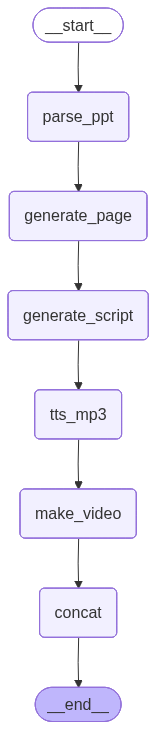

In [49]:
app

## **4. 시스템 실행**

미션3,4에서 수행한 결과를 통합 테스트 해 봅시다.

### (1) 준비 작업
* 파일 업로드
* 사용자 프롬프트 준비

In [ ]:
# # 파일 업로드
uploaded = files.upload()
pptx_path = list(uploaded.keys())[0]

Saving sample2_test.pptx to sample2_test (1).pptx


In [113]:
# 사용자 프롬프트
USER_PROMPT = {
	# "voice": "alloy",
	"tone": "차분",
	"style": "예시와 핵심 요점 중심"
}
# 출력 dir 만들기
WORK_DIR = "./step1_output"
MEDIA_DIR = "./step1_output/media"
os.makedirs(WORK_DIR, exist_ok=True)
os.makedirs(MEDIA_DIR, exist_ok=True)

### (2) Agent 실행
* State 초기화
* app 실행
	* 실행 시, 잘못된 반복 실행이 발생될 수 있으므로 다음 옵션 적용
		* `app.invoke(state, config={"recursion_limit": 100})`
		* 숫자 100은 조정 가능
* 동영상 play

In [ ]:
# @title
state: State = {
	"pptx_path": pptx_path,
	# "slide_image": [slide_image_path],
	"prompt": USER_PROMPT,
	"work_dir": WORK_DIR,
	"media_dir": MEDIA_DIR,
}

In [114]:
# 초기 State 예시
state: State = {
	"pptx_path": pptx_path,
	"prompt": USER_PROMPT,
	"work_dir": WORK_DIR,
	"media_dir": MEDIA_DIR,
}

In [115]:
# 전체 그래프 실행
state = app.invoke(state, config={"recursion_limit": 100})

[INFO] Page 0: 텍스트 14개, 표 0개, 이미지 1개 추출 완료.


TypeError: SlideData.__init__() missing 1 required positional argument: 'slide_image'

In [ ]:
# 영상 재생
video_path = state['final_video'][0].video

with open(video_path, "rb") as f:
	data = f.read()
display(Video(data=data, embed=True, mimetype="video/mp4", width=960))

KeyError: 'final_video'

## **5. Web APP 개발(Gradio)**
* 화면 개발
	* 입력 : ppt파일, 프롬프트(강의 작성톤), voice 선택(alloy, ...)
	* 출력 : 동영상 play, 동영상 다운로드 버튼
* 기본 화면을 제공합니다. 필요한 기능을 직접 추가하세요.

In [ ]:
import os, time, shutil
import gradio as gr

VOICES = ["alloy", "aria", "verse", "shimmer", "coral", "sage", "tenor", "nova", "amber"]

def run_pipeline_ui(pptx_file, tone, voice):

	# 작업 디렉터리 & 업로드 저장
	work_dir = os.path.join("./webio", f"run-{int(time.time())}")
	os.makedirs(work_dir, exist_ok=True)
	pptx_path = os.path.join(work_dir, "input.pptx")
	shutil.copy(pptx_file.name, pptx_path)

	# 초기 state (State 스키마에 맞춤)
	state = {
		"pptx_path": pptx_path,
		"work_dir": work_dir,
		"prompt": {
			"voice": voice or "alloy",
			"tone":  tone or "친절하고 명료한 강의 톤",
			"style": "예시와 핵심 요점 중심",
		},
	}

	# 그래프 실행
	final_state = app.invoke(state)
	video_path = final_state.get("final_video")

	return video_path, video_path

# -------------------- Gradio UI --------------------
with gr.Blocks(title="AI 강사 Agent") as demo:
	gr.Markdown("### PPT → 강의영상 자동 제작")

	with gr.Row():
		inp_ppt = gr.File(label="PPTX 업로드", file_types=[".pptx"])
		with gr.Column():
			inp_tone  = gr.Textbox(value="친절하고 명료한 강의 톤", label="강의 작성 톤 (프롬프트)")
			inp_voice = gr.Dropdown(VOICES, value="alloy", label="TTS Voice")

	run_btn = gr.Button("실행", variant="primary")

	out_video    = gr.Video(label="최종 동영상 미리보기", interactive=False)
	out_download = gr.DownloadButton(label="동영상 다운로드")

	run_btn.click(run_pipeline_ui, [inp_ppt, inp_tone, inp_voice], [out_video, out_download])

demo.launch()